In [ ]:
# Instalación y Preparación del Entorno
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Instalación de dependencias
!pip install compressai
!pip install pytorch-msssim
!pip install ipywidgets

# Importar librerías
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
from torch.utils.data import DataLoader
from torchvision import transforms
from compressai.zoo import cheng2020_anchor
from compressai.losses import RateDistortionLoss
from PIL import Image
import os
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo activo: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.4 MB/s eta 0:00:00
Dispositivo activo: cuda


Imágenes de entrenamiento cargadas: 800


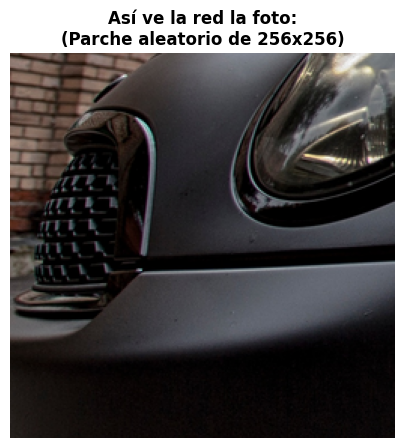

In [ ]:
# Dataset de Entrenamiento (Parches 256x256)
# Transformación para Entrenamiento: Parches aleatorios de 256x256
train_transforms = transforms.Compose([
    transforms.RandomCrop(256),
    transforms.ToTensor()
])

class TrainDatasetDIV2K(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert("RGB")
        return train_transforms(img)


ruta_train = '/content/drive/MyDrive/Curso4/TFG/DIV2K_HR_IMAGES/DIV2K_train_HR'
train_dataset = TrainDatasetDIV2K(ruta_train)
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
print(f"Imágenes de entrenamiento cargadas: {len(train_dataset)}")

lote_ejemplo = next(iter(train_dataloader))
imagen_visualizar = lote_ejemplo[0].permute(1, 2, 0).numpy()
plt.figure(figsize=(5, 5))
plt.imshow(imagen_visualizar)
plt.title("Así ve la red la foto:\n(Parche aleatorio de 256x256)", fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

Imágenes de validación cargadas: 100


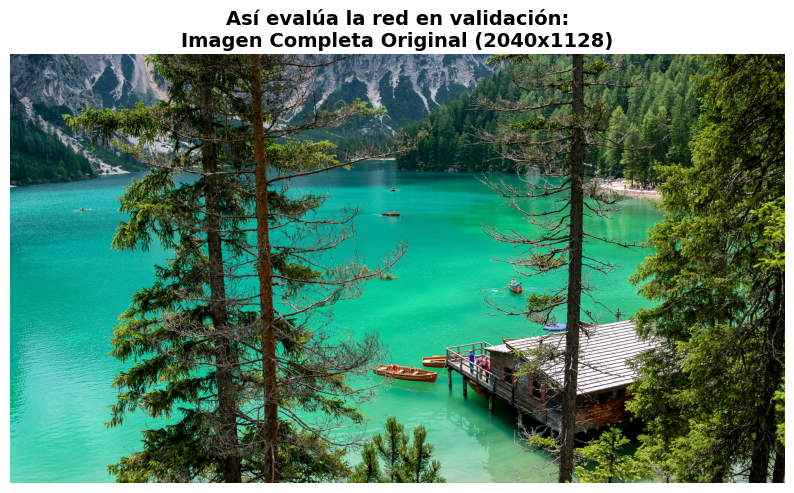

In [ ]:
# Dataset de Validación (Imagen Completa)
# Transformación para Validación: IMAGEN COMPLETA ORIGINAL
valid_transforms = transforms.Compose([
    transforms.ToTensor()
])

class ValidDatasetDIV2K(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert("RGB")
        return valid_transforms(img)

ruta_valid = "/content/drive/MyDrive/Curso4/TFG/DIV2K_HR_IMAGES/DIV2K_valid_HR"
valid_dataset = ValidDatasetDIV2K(ruta_valid)
# Batch_size = 1 es obligatorio porque las imágenes completas tienen tamaños distintos entre sí
valid_dataloader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
print(f"Imágenes de validación cargadas: {len(valid_dataset)}")

lote_val_ejemplo = next(iter(valid_dataloader))
imagen_val_visualizar = lote_val_ejemplo[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 6))
plt.imshow(imagen_val_visualizar)
plt.title(f"Así evalúa la red en validación:\nImagen Completa Original ({imagen_val_visualizar.shape[1]}x{imagen_val_visualizar.shape[0]})", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [ ]:
def calcular_ranking_empirico(modelo, dataloader, device):
    """Calcula qué canales tienen más energía media en el dataset de validación"""
    print("Perfilando el dataset de validación para extraer el ranking empírico...")

    # Aseguramos que el modelo esté en el dispositivo correcto y en modo evaluación
    modelo = modelo.to(device)
    modelo.eval()

    energia_total = None
    num_imagenes = 0

    with torch.no_grad():
        for lote in dataloader:
            # El dataloader devuelve directamente el tensor de la imagen (Batch, C, H, W)
            img = lote.to(device)

            # APLICAMOS PADDING DE SEGURIDAD
            # Como son imágenes completas, forzamos que sean múltiplo de 64
            _, _, h, w = img.size()
            pad_h = (64 - (h % 64)) % 64
            pad_w = (64 - (w % 64)) % 64
            img_padded = F.pad(img, (0, pad_w, 0, pad_h))

            # Detectamos si es el modelo original de CompressAI o el envoltorio adaptativo
            if hasattr(modelo, 'base_model'):
                y_puro = modelo.base_model.g_a(img_padded)
            else:
                y_puro = modelo.g_a(img_padded)

            # Calculamos la energía media absoluta por canal (destruyendo Batch, Alto y Ancho)
            energia_lote = torch.mean(torch.abs(y_puro), dim=(0, 2, 3))

            # Acumulamos
            if energia_total is None:
                energia_total = energia_lote
            else:
                energia_total += energia_lote
            num_imagenes += 1

    # Media global y cálculo del ranking
    energia_media_global = energia_total / num_imagenes
    ranking_indices = torch.argsort(energia_media_global, descending=True)

    print(f"Ranking calculado sobre {num_imagenes} imágenes.")
    print(f"Canal con MÁS energía: {ranking_indices[0].item()} | MENOR energía: {ranking_indices[-1].item()}")

    return ranking_indices

In [ ]:
# Arquitectura del Modelo Adaptativo y Loss
class AdaptiveCheng2020Anchor(nn.Module):
    def __init__(self, ranking_empirico=None):
        super().__init__()
        # Inicializamos el modelo (Quality 3 usa 128 canales por defecto)
        self.base_model = cheng2020_anchor(quality=3, pretrained=False)

        # Gestión del Ranking
        if ranking_empirico is None:
            # Si no damos ranking, orden secuencial normal (0, 1, 2... 127)
            self.register_buffer('ranking_empirico', torch.arange(128))
        else:
            self.register_buffer('ranking_empirico', ranking_empirico)

    def forward(self, x, active_channels_ratio):
        # Extracción latente
        y = self.base_model.g_a(x)

        # Mecanismo de descarte dinámico (Máscara Empírica)
        N = y.size(1) # Dinámicamente detecta que son 128 canales
        c_keep = int(N * active_channels_ratio)
        mask = torch.zeros_like(y)

        if c_keep > 0:
            # Usamos el ranking_empirico
            canales_activos = self.ranking_empirico[:c_keep]
            mask[:, canales_activos, :, :] = 1.0
        y_masked = y * mask

        # ========================================================
        #  CHENG2020
        # ========================================================

        # Flujo del Hiperprior
        z = self.base_model.h_a(y_masked)
        z_hat, z_likelihoods = self.base_model.entropy_bottleneck(z)
        params = self.base_model.h_s(z_hat)

        # Predicción de Contexto
        # Simulamos la cuantificación (con ruido en entrenamiento, redondeo en inferencia)
        y_hat = self.base_model.gaussian_conditional.quantize(
            y_masked, "noise" if self.training else "dequantize"
        )

        # La red mira a los "vecinos" para predecir el siguiente valor
        ctx_params = self.base_model.context_prediction(y_hat)

        # Juntamos la predicción del hiperprior (params) y la de los vecinos (ctx_params)
        gaussian_params = self.base_model.entropy_parameters(
            torch.cat((params, ctx_params), dim=1)
        )

        # Separamos las escalas y las medias para la probabilidad gaussiana
        scales_hat, means_hat = gaussian_params.chunk(2, 1)


        y_for_likelihood = y_masked.clone()
        y_for_decoder = y_hat.clone()

        if c_keep < N:
            # Identificamos qué canales exactamente se han quedado apagados
            canales_inactivos = self.ranking_empirico[c_keep:]

            # Inyectamos la media en esos canales específicos
            y_for_likelihood[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]
            y_for_decoder[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]

        # Cálculo final de Entropía y Síntesis (usamos los tensores con la media inyectada)
        _, y_likelihoods = self.base_model.gaussian_conditional(y_for_likelihood, scales_hat, means_hat)
        x_hat = self.base_model.g_s(y_for_decoder)

        return {
            'x_hat': x_hat,
            'likelihoods': {'y': y_likelihoods, 'z': z_likelihoods},
            "y": y
        }

def adaptive_rd_loss(out_net, target_image, active_ratio):
    lambda_max, lambda_min = 0.1, 0.0018
    current_lambda = lambda_min + (lambda_max - lambda_min) * active_ratio
    criterion = RateDistortionLoss(lmbda=current_lambda, metric='mse')

    # rd_loss es un diccionario que contiene "loss" (el total de R+D)
    rd_loss = criterion(out_net, target_image)

    # =======================================================
    # EXTRACCIÓN DE LA ENERGÍA (E_c)
    # =======================================================
    y = out_net['y'] # Dimensiones: (Batch, Canales, Alto, Ancho)

    # Calculamos la energía media absoluta de cada canal
    # Hacemos la media sobre el Batch (0), Alto (2) y Ancho (3), quedando solo con los Canales (1)
    E_c = torch.mean(torch.abs(y), dim=(0, 2, 3))

    # Epsilon de seguridad matemática para evitar divisiones por 0, log(0) o sqrt(0)
    eps = 1e-9

    # =======================================================
    # ENTROPÍA DE LA ENERGÍA (H) - Fomenta la desigualdad
    # =======================================================
    # p_c = E_c / sum_c(E_c)
    p_c = E_c / (torch.sum(E_c) + eps)

    # H = - sum_c(p_c * log(p_c))
    H = -torch.sum(p_c * torch.log(p_c + eps))

    # =======================================================
    # REGULADOR LASSO CON RAÍZ (S) - Fomenta canales a cero (Sparsity)
    # =======================================================
    # S = sum_c(sqrt(E_c))
    S = torch.sum(torch.sqrt(E_c + eps))

    # =======================================================
    # CÁLCULO DEL LOSS TOTAL
    # =======================================================
    # Estos hiperparámetros (\lambda_H y \lambda_L) deciden cuánta "fuerza"
    lambda_H = 0.01
    lambda_L = 0.005

    loss_total = rd_loss["loss"] + (lambda_H * H) + (lambda_L * S)

    # Devolvemos un diccionario.
    return {
        "loss": loss_total,          # El coste que la red intentará minimizar
        "rd_loss": rd_loss["loss"],
        "H": H,
        "S": S
    }

modelo_temporal=cheng2020_anchor(quality=3, pretrained=True)
ranking_empirico = calcular_ranking_empirico(modelo_temporal, valid_dataloader, device)
model = AdaptiveCheng2020Anchor(ranking_empirico = ranking_empirico).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020-anchor-3-e49be189.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020-anchor-3-e49be189.pth.tar


100%|██████████| 49.1M/49.1M [00:01<00:00, 50.2MB/s]


Perfilando el dataset de validación para extraer el ranking empírico...
Ranking calculado sobre 100 imágenes.
Canal con MÁS energía: 119 | MENOR energía: 27


In [ ]:
from tqdm import tqdm

epochs = 50

# Listas para guardar el histórico y poder pintarlo en una gráfica después
historial_train_loss = []
historial_val_loss = []

for epoch in range(epochs):
    print(f"\n=================== ÉPOCA {epoch+1}/{epochs} ===================")

    # ---------------------------------------------------------
    # FASE DE ENTRENAMIENTO
    # ---------------------------------------------------------
    model.train()
    train_loss_total = 0.0

    # Envolvemos el dataloader con tqdm para la barra de progreso
    train_bar = tqdm(train_dataloader, desc="Entrenando ", leave=False)

    for i, images in enumerate(train_bar):
        images = images.to(device)
        optimizer.zero_grad()

        # Ratio aleatorio para forzar a la red a ser adaptativa
        random_ratio = torch.empty(1).uniform_(0.1, 1.0).item()

        out_net = model(images, random_ratio)
        loss = adaptive_rd_loss(out_net, images, random_ratio)

        loss["loss"].backward()
        optimizer.step()

        # Sumamos el loss y actualizamos el texto de la barra de carga
        train_loss_total += loss["loss"].item()
        train_bar.set_postfix({'loss': f'{loss["loss"].item():.4f}', 'ratio': f'{random_ratio:.2f}'})

    avg_train_loss = train_loss_total / len(train_dataloader)
    historial_train_loss.append(avg_train_loss)

    # ---------------------------------------------------------
    # FASE DE VALIDACIÓN
    # ---------------------------------------------------------
    model.eval()
    val_loss_total = 0.0

    val_bar = tqdm(valid_dataloader, desc="Validando  ", leave=False)

    with torch.no_grad():
        for images in val_bar:
            images = images.to(device)

            # Aplicamos Padding porque valid_dataloader trae imágenes completas
            _, _, h, w = images.size()
            pad_h = (64 - (h % 64)) % 64
            pad_w = (64 - (w % 64)) % 64
            images_padded = F.pad(images, (0, pad_w, 0, pad_h))

            # Usamos un ratio fijo (1.0 = 100% de canales) para tener una métrica estable
            eval_ratio = 1.0

            out_net = model(images_padded, eval_ratio)
            loss = adaptive_rd_loss(out_net, images_padded, eval_ratio)

            val_loss_total += loss["loss"].item()
            val_bar.set_postfix({'val_loss': f'{loss["loss"].item():.4f}'})

    avg_val_loss = val_loss_total / len(valid_dataloader)
    historial_val_loss.append(avg_val_loss)

    # ---------------------------------------------------------
    # RESUMEN DE LA ÉPOCA
    # ---------------------------------------------------------
    print(f"✅ FIN ÉPOCA {epoch+1} | Train Loss Media: {avg_train_loss:.4f} | Valid Loss Media (100% cap): {avg_val_loss:.4f}")


=================== ÉPOCA 1/50 ===================


✅ FIN ÉPOCA 1 | Train Loss Media: 40.1043 | Valid Loss Media (100% cap): 44.3931

=================== ÉPOCA 2/50 ===================


✅ FIN ÉPOCA 2 | Train Loss Media: 13.8156 | Valid Loss Media (100% cap): 23.7469

=================== ÉPOCA 3/50 ===================


✅ FIN ÉPOCA 3 | Train Loss Media: 10.4765 | Valid Loss Media (100% cap): 19.7318

=================== ÉPOCA 4/50 ===================


✅ FIN ÉPOCA 4 | Train Loss Media: 8.3678 | Valid Loss Media (100% cap): 15.1741

=================== ÉPOCA 5/50 ===================


...

✅ FIN ÉPOCA 46 | Train Loss Media: 5.2779 | Valid Loss Media (100% cap): 9.3974

=================== ÉPOCA 47/50 ===================


✅ FIN ÉPOCA 47 | Train Loss Media: 4.5048 | Valid Loss Media (100% cap): 3.8671

=================== ÉPOCA 48/50 ===================


✅ FIN ÉPOCA 48 | Train Loss Media: 2.9295 | Valid Loss Media (100% cap): 3.5406

=================== ÉPOCA 49/50 ===================


✅ FIN ÉPOCA 49 | Train Loss Media: 2.5511 | Valid Loss Media (100% cap): 3.3040

=================== ÉPOCA 50/50 ===================


✅ FIN ÉPOCA 50 | Train Loss Media: 2.5442 | Valid Loss Media (100% cap): 3.3028


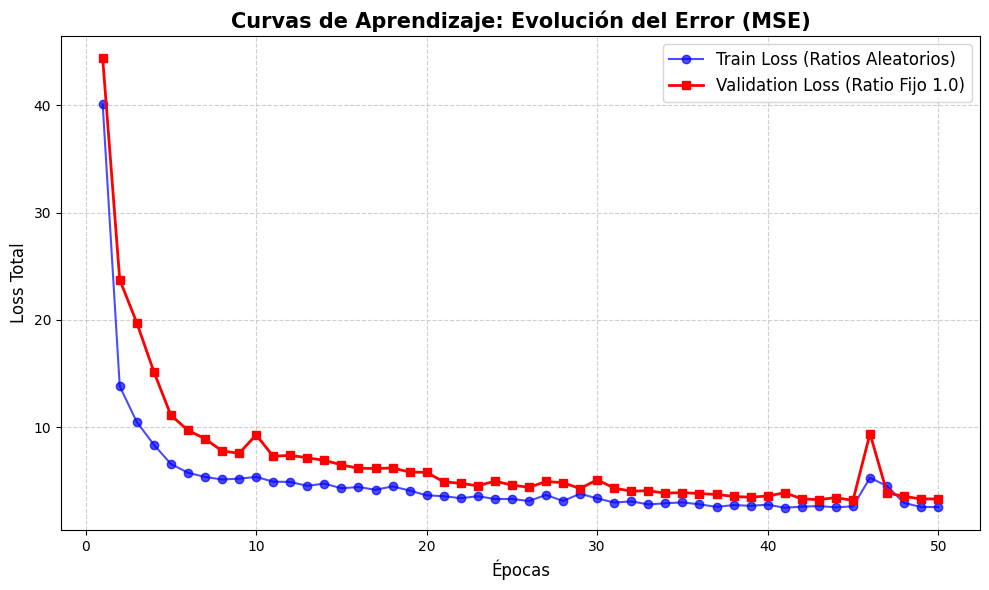

In [ ]:
# Curva Losses
plt.figure(figsize=(10, 6))

plt.plot(range(1, epochs + 1), historial_train_loss, label='Train Loss (Ratios Aleatorios)', color='blue', marker='o', alpha=0.7)
plt.plot(range(1, epochs + 1), historial_val_loss, label='Validation Loss (Ratio Fijo 1.0)', color='red', marker='s', linewidth=2)

plt.title('Curvas de Aprendizaje: Evolución del Error (MSE)', fontsize=15, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss Total', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
ruta_guardado_manual = '/content/drive/MyDrive/Curso4/TFG/CHENG2020_Q3_MSE_0018_1_H_01_S_005_DataDriven.pth'
torch.save(model.state_dict(), ruta_guardado_manual)

print(f"Modelo guardado con éxito en: {ruta_guardado_manual}")

Modelo guardado con éxito en: /content/drive/MyDrive/Curso4/TFG/CHENG2020_Q3_MSE_0018_01_H_01_S_005_DataDriven.pth
